In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import tensorflow as tf
from tensorflow import keras
from keras.models import Model
from keras.layers import *

2025-10-21 06:36:24.894779: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-10-21 06:36:28.516526: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-10-21 06:38:56.563059: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [3]:
#define two sets of Inputs
inputA=Input(shape=(32,))
inputB=Input(shape=(128,))

In [4]:
#the first branch operates the fist i/p
x=Dense(8,activation='relu')(inputA)
x1=Dense(128,activation='relu')(x)

I0000 00:00:1761028799.783873    3408 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1765 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


In [5]:
# the second branh operates on the second input

y=Dense(64,activation='relu')(inputB)
y1=Dense(32,activation='relu')(y)
y2=Dense(4,activation='relu')(y1)

In [6]:
#combin the o/p 
combined=concatenate([x1,y2])

In [7]:
z=Dense(2,activation='relu')(combined)
z1=Dense(1,activation='linear')(z)

In [10]:
#model will accept the inputs of the two branches and then o/p in a single value

model=Model(inputs=[inputA,inputB],outputs=z)

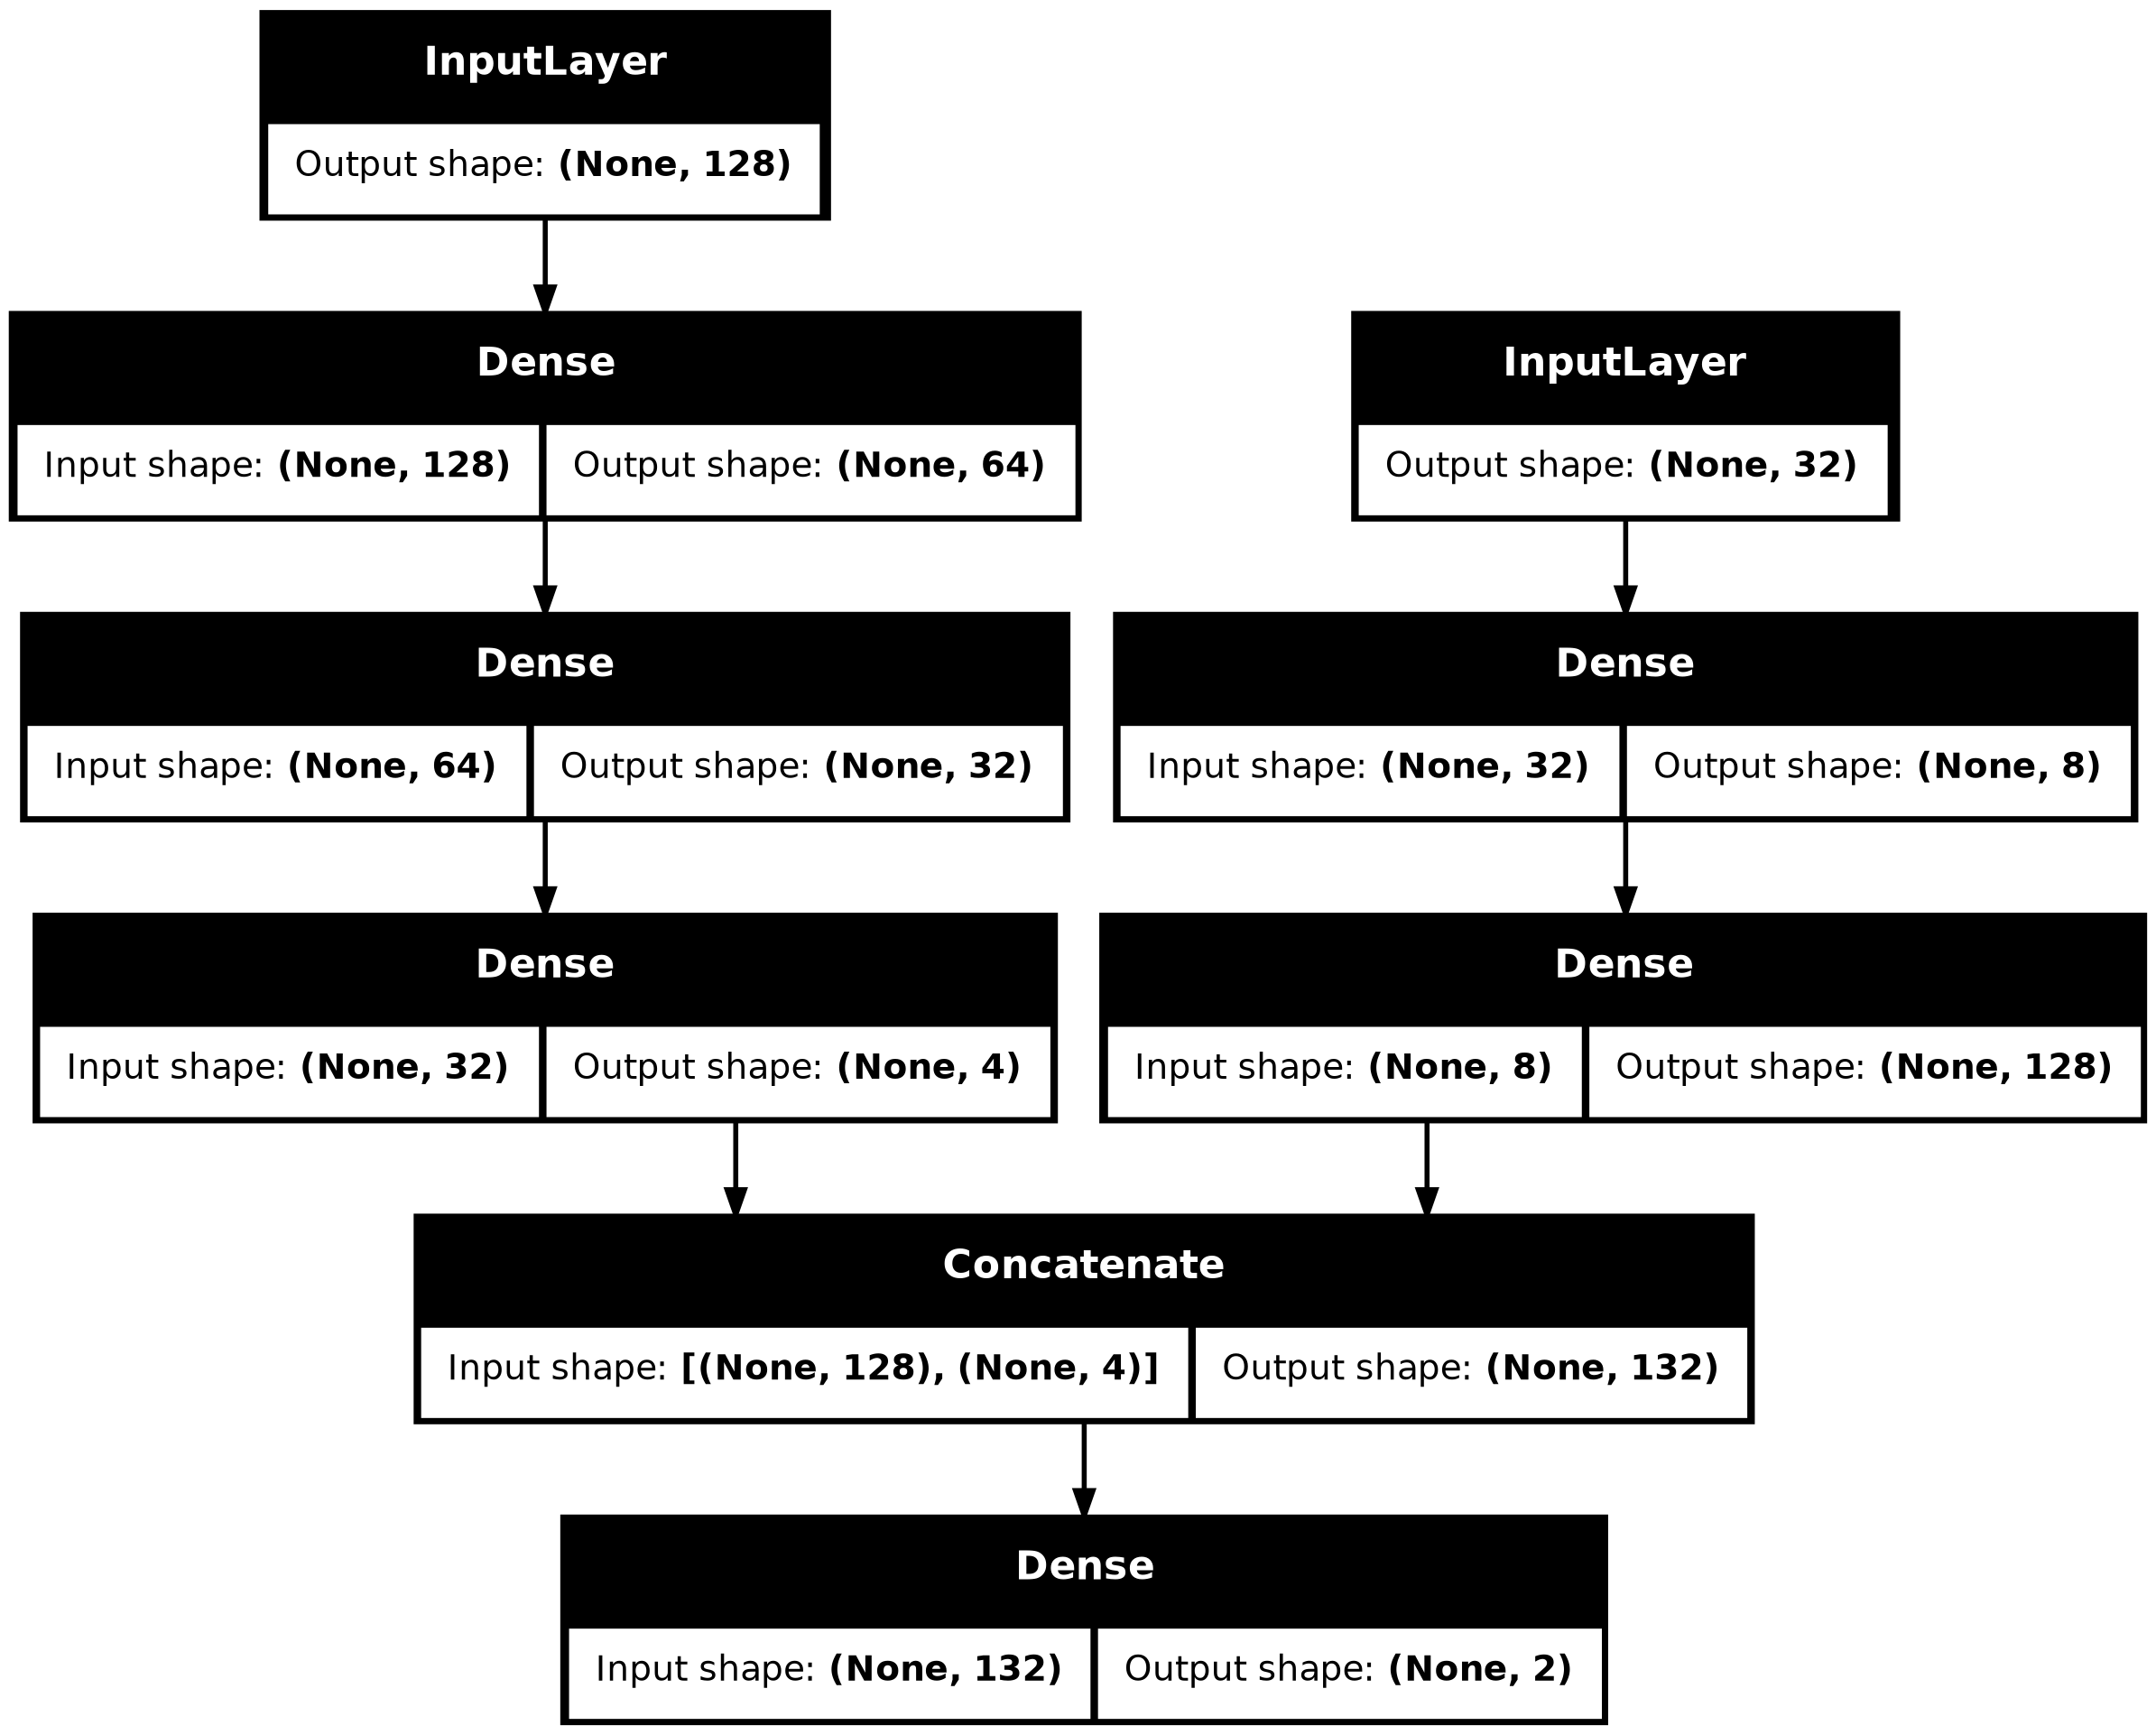

In [12]:
from keras.utils import plot_model
plot_model(model,show_shapes=True)